/Users/boud/mlpractical/final_project/open_clip
Embeddings shape: (59551, 128)
Super class IDs shape: (59551,)


/Users/boud/anaconda3/envs/ML/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

embeddings_tensor = torch.from_numpy(embeddings).float().to(device)
embeddings_tensor = torch.nn.functional.normalize(embeddings_tensor, dim=1)

N = embeddings_tensor.shape[0]

block_size = 2000   # tune based on memory
cosine_vals = []
match_flags = []

for i in tqdm(range(0, N, block_size)):
    end_i = min(i + block_size, N)
    block_i = embeddings_tensor[i:end_i]

    for j in range(i, N, block_size):
        end_j = min(j + block_size, N)
        block_j = embeddings_tensor[j:end_j]

        sim = block_i @ block_j.T   # GPU fast

        if i == j:
            # keep only upper triangle
            mask = torch.triu(torch.ones_like(sim), diagonal=1).bool()
        else:
            mask = torch.ones_like(sim).bool()

        sim_vals = sim[mask].cpu().numpy()

        cosine_vals.append(sim_vals)

        # build match labels
        ids_i = super_class_ids[i:end_i]
        ids_j = super_class_ids[j:end_j]

        label_block = (ids_i[:, None] == ids_j[None, :])
        match_flags.append(label_block[mask.cpu().numpy()])

cosine_vals = np.concatenate(cosine_vals)
match_flags = np.concatenate(match_flags)

cosine_sim_match = cosine_vals[match_flags]
cosine_sim_nonmatch = cosine_vals[~match_flags]


100%|██████████| 31/31 [00:09<00:00,  3.27it/s]


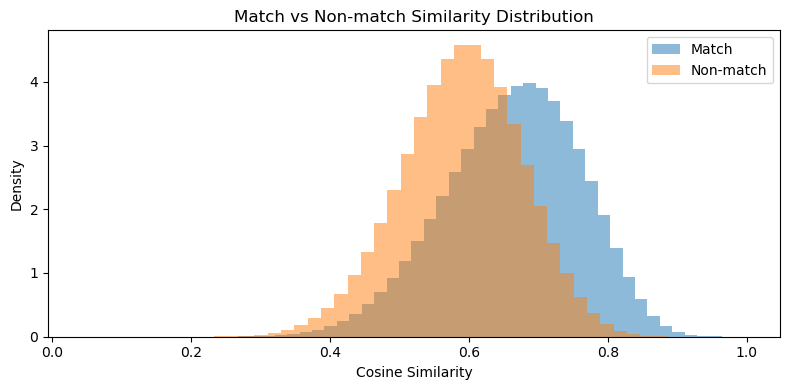

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(cosine_sim_match, bins=50, alpha=0.5, density=True, label="Match")
plt.hist(cosine_sim_nonmatch, bins=50, alpha=0.5, density=True, label="Non-match")

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("Match vs Non-match Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import torch
import numpy as np
from tqdm import tqdm

%cd /Users/boud/mlpractical/final_project/open_clip/
import numpy as np

# Load results
embeddings = np.load('/Users/boud/mlpractical/final_project/open_clip/embeddings/ViT-B_32_baseline_embeddings.npy')
super_class_ids = np.load('/Users/boud/mlpractical/final_project/open_clip/embeddings/ViT-B_32_finetuned_simCLR_super_class_ids.npy')

print(f"Embeddings shape: {embeddings.shape}")  # (N, 512)
print(f"Super class IDs shape: {super_class_ids.shape}")  # (N,)


# ---- Device ----
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ---- Convert to tensors ----
emb = torch.from_numpy(embeddings).float().to(device)
labels = torch.from_numpy(super_class_ids).to(device)

# ---- Normalize embeddings (cosine similarity) ----
emb = torch.nn.functional.normalize(emb, dim=1)

N = emb.shape[0]

# ---- Retrieval parameters ----
Ks = [1, 100, 1000]
recall_hits = {k: 0 for k in Ks}

batch_size = 512   # adjust if memory allows

# ---- Compute retrieval ----
for i in tqdm(range(0, N, batch_size)):
    end = min(i + batch_size, N)

    query = emb[i:end]                  # (B, D)
    query_labels = labels[i:end]        # (B,)

    # cosine similarity
    sim = query @ emb.T                # (B, N)

    # remove self match
    for j in range(sim.shape[0]):
        sim[j, i + j] = -1.0

    # top-k retrieval
    max_k = max(Ks)
    topk_idx = torch.topk(sim, max_k, dim=1).indices   # (B, max_k)

    retrieved_labels = labels[topk_idx]               # (B, max_k)

    # check if correct class appears in top-K
    for k in Ks:
        correct = (retrieved_labels[:, :k] == query_labels.unsqueeze(1)).any(dim=1)
        recall_hits[k] += correct.sum().item()

# ---- Final recall ----
for k in Ks:
    print(f"Recall@{k}: {recall_hits[k] / N:.4f}")


/Users/boud/anaconda3/envs/ML/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/boud/mlpractical/final_project/open_clip
Embeddings shape: (60502, 512)
Super class IDs shape: (60502,)


100%|██████████| 119/119 [00:12<00:00,  9.35it/s]

Recall@1: 0.9044
Recall@100: 0.9991
Recall@1000: 1.0000
